# Prática Acessando o Neo4J do Google Colab


Instale as dependências

In [16]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Crie uma conta gratuita no Neo4J Aura em: https://neo4j.com/cloud/platform/auradb

Em seguida, crie um instancia de banco e obtenha os dados abaixo:  

In [22]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path='.env')

NEO4J_URI=os.getenv("NEO4J_URI")
NEO4J_USERNAME=os.getenv("NEO4J_USERNAME")
NEO4J_DATABASE=os.getenv("NEO4J_DATABASE")
AURA_INSTANCEID=os.getenv("AURA_INSTANCEID")
AURA_INSTANCENAME=os.getenv("AURA_INSTANCENAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")

Testando a instância

In [21]:
import os
from pathlib import Path

from neo4j import GraphDatabase

if not NEO4J_PASSWORD:
    raise ValueError("A variável NEO4J_PASSWORD não foi definida no arquivo .env.")

# Executando uma consulta simples
with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME,NEO4J_PASSWORD)) as driver:
    driver.verify_connectivity()

    # Criando um nó de exemplo
    with driver.session() as session:
        session.run("CREATE (p:Pessoa {nome: 'Fabricio'}) RETURN p")
        print("Conectado e nó criado com sucesso!")

Conectado e nó criado com sucesso!


Verifique no Neo4J Aura Bloom o estado do seu grafo

In [19]:
with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME,NEO4J_PASSWORD)) as driver:

    driver.verify_connectivity()

    # Clear existing data before adding new nodes/relationships
    with driver.session() as session:
        session.run("MATCH (n) DETACH DELETE n")
        print("Existing nodes and relationships deleted.")



Existing nodes and relationships deleted.


# Verificando o grafo no Neo4J
No Neo4J, selecione query e digite o comando:
``` cypher
 MATCH (n)
 RETURN (n)
  ```

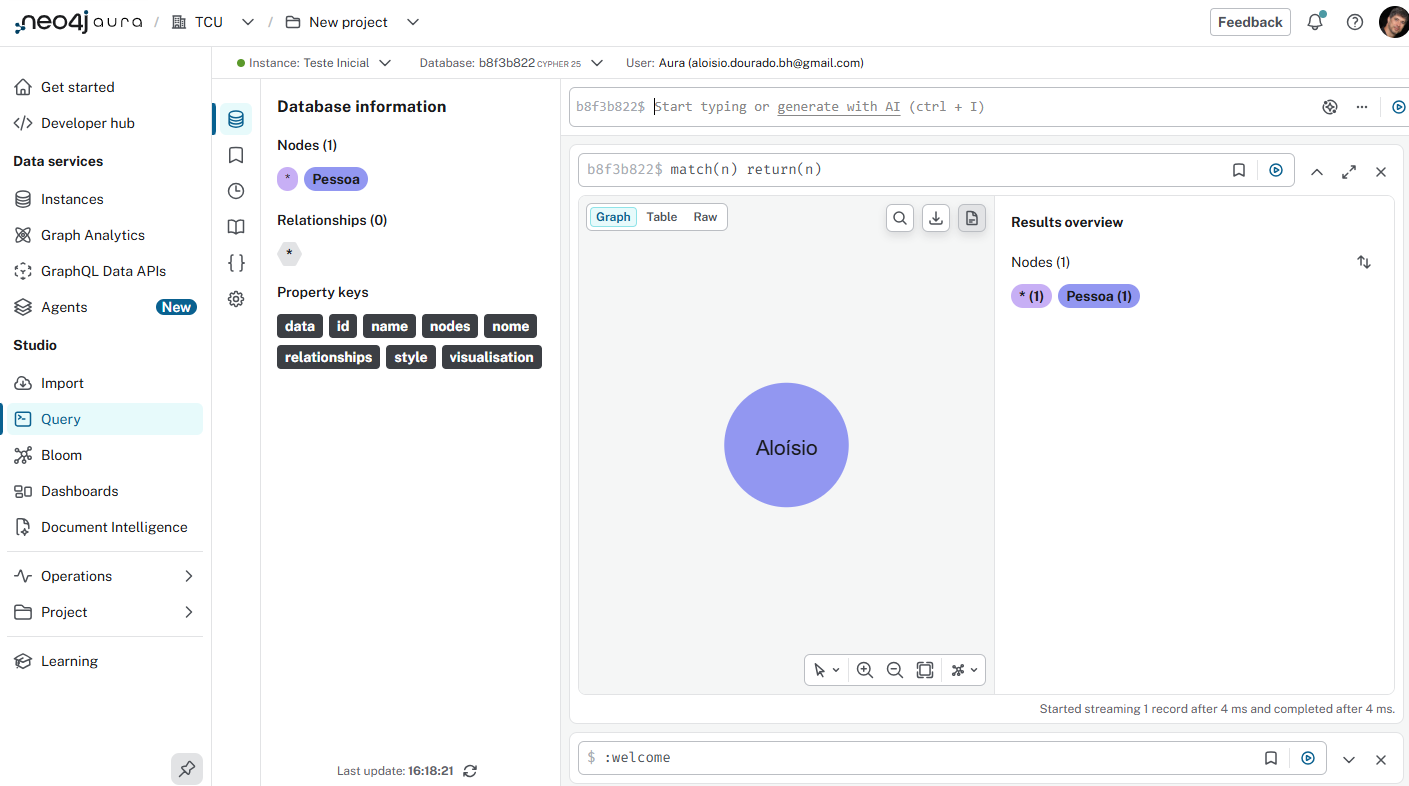

## Criando um grafo mais complexo

Observação: CREATE vs. MERGE no Cypher
CREATE: O comando CREATE sempre cria novos nós ou relacionamentos. Se você tentar criar um nó ou relacionamento que já existe, o Cypher simplesmente adicionará uma duplicata. Isso pode levar a dados redundantes se você não tiver certeza sobre a existência do nó/relacionamento.

**Exemplo**: CREATE (p:Pessoa {nome: 'Aloísio'}) sempre criará um novo nó para Aloísio, mesmo que um já exista.
MERGE: O comando MERGE é mais inteligente. Ele tenta encontrar um padrão no grafo. Se o padrão for encontrado, ele o corresponderá (não criando nada novo). Se o padrão não for encontrado, ele o criará. É ideal quando você deseja garantir que um nó ou relacionamento exista, mas não quer criar duplicatas.

**Exemplo**: MERGE (p:Pessoa {nome: 'Iris'}) procurará por uma pessoa chamada 'Iris'. Se encontrar, usará esse nó; caso contrário, criará um novo.

In [12]:
with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME,NEO4J_PASSWORD)) as driver:

    driver.verify_connectivity()

    with driver.session() as session:

      # Create or merge person nodes
      session.run("MERGE (p:Pessoa {nome: 'Paulo'}) RETURN p")
      session.run("MERGE (p:Pessoa {nome: 'Eduardo'})")
      session.run("MERGE (p:Pessoa {nome: 'Fabricio'})")
      session.run("MERGE (p:Pessoa {nome: 'Davson'})")
      session.run("MERGE (p:Pessoa {nome: 'Maria'})")
      session.run("MERGE (p:Pessoa {nome: 'Yuri'})")
      session.run("MERGE (p:Pessoa {nome: 'Pietro'})")
      session.run("MERGE (p:Pessoa {nome: 'Stella'})")
      session.run("MERGE (p:Pessoa {nome: 'Leticia'})")
      session.run("MERGE (p:Pessoa {nome: 'Arthur'})")
      print("Person nodes merged/created.")

      # Create relationships
      session.run("MATCH (a:Pessoa {nome: 'Paulo'}), (i:Pessoa {nome: 'Davson'}) CREATE (a)-[:PAI_DE]->(i)")
      session.run("MATCH (a:Pessoa {nome: 'Paulo'}), (j:Pessoa {nome: 'Eduardo'}) CREATE (a)-[:PAI_DE]->(j)")
      session.run("MATCH (a:Pessoa {nome: 'Paulo'}), (l:Pessoa {nome: 'Fabricio'}) CREATE (a)-[:PAI_DE]->(l)")
      print("Paulo's children relationships created.")

      session.run("MATCH (a:Pessoa {nome: 'Paulo'}), (c:Pessoa {nome: 'Maria'}) CREATE (a)-[:CASADO_COM]->(c)")
      print("Paulo and Maria's marriage relationship created.")

      session.run("MATCH (l:Pessoa {nome: 'Fabricio'}), (g:Pessoa {nome: 'Renata'}) CREATE (l)-[:CASADO_COM]->(g)")
      print("Fabricio and Renatas's marriage relationship created.")

      session.run("MATCH (j:Pessoa {nome: 'Eduardo'}), (v:Pessoa {nome: 'Pietro'}) CREATE (j)-[:PAI_DE]->(v)")
      session.run("MATCH (j:Pessoa {nome: 'Eduardo'}), (v:Pessoa {nome: 'Stella'}) CREATE (j)-[:PAI_DE]->(v)")
      print("Eduardo's dad-child relationship created.")

      session.run("MATCH (j:Pessoa {nome: 'Davson'}), (v:Pessoa {nome: 'Leticia'}) CREATE (j)-[:PAI_DE]->(v)")
      session.run("MATCH (j:Pessoa {nome: 'Davson'}), (v:Pessoa {nome: 'Arthur'}) CREATE (j)-[:PAI_DE]->(v)")
      print("Davson's dad-child relationship created.")

      session.run("MATCH (j:Pessoa {nome: 'Fabricio'}), (v:Pessoa {nome: 'Yuri'}) CREATE (j)-[:PAI_DE]->(v)")
      print("Davson's dad-child relationship created.")

      session.run("MATCH (c:Pessoa {nome: 'Maria'}), (i:Pessoa {nome: 'Davson'}) CREATE (c)-[:MAE_DE]->(i)")
      session.run("MATCH (c:Pessoa {nome: 'Maria'}), (j:Pessoa {nome: 'Eduardo'}) CREATE (c)-[:MAE_DE]->(j)")
      session.run("MATCH (c:Pessoa {nome: 'Maria'}), (l:Pessoa {nome: 'Fabricio'}) CREATE (c)-[:MAE_DE]->(l)")
      print("Fabricio's children relationships created.")


Person nodes merged/created.
Paulo's children relationships created.
Paulo and Maria's marriage relationship created.
Fabricio and Renatas's marriage relationship created.
Eduardo's dad-child relationship created.
Davson's dad-child relationship created.
Davson's dad-child relationship created.
Fabricio's children relationships created.


Verifique o grafo com:
``` cypher
MATCH (n)
OPTIONAL MATCH (n)-[r]->(m)
RETURN n, r, m
```

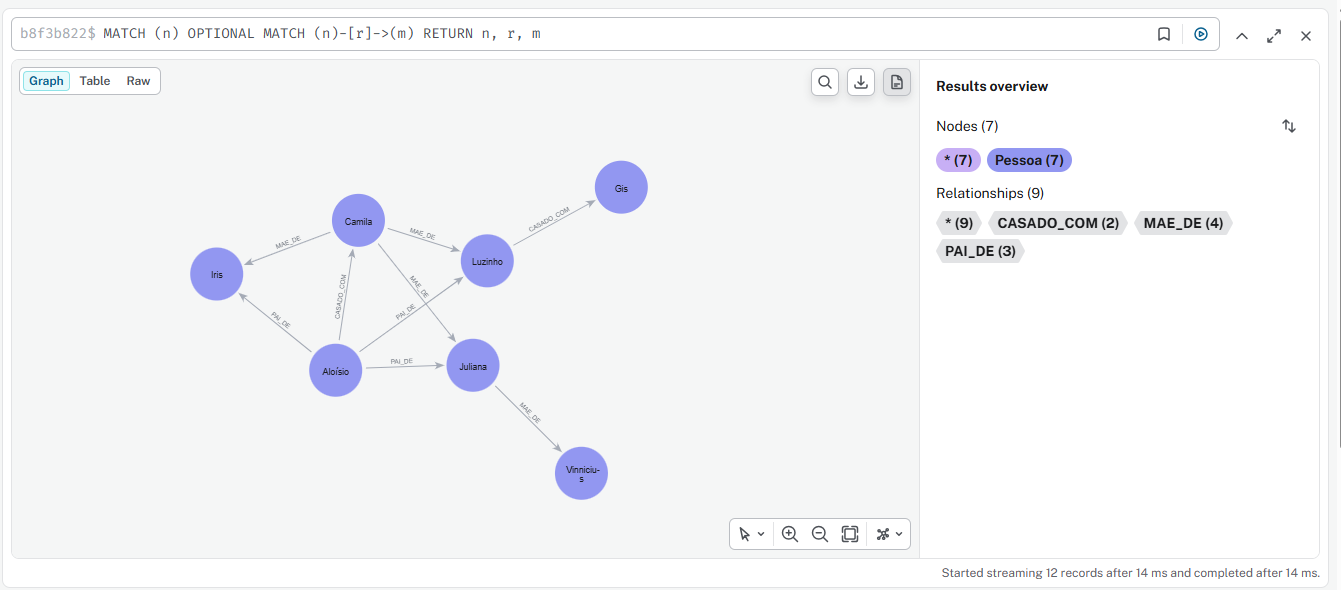

# Carregando o grafo a partir de dados em lista de maneira mais eficiente

In [14]:
from neo4j import GraphDatabase

# Connect to the Neo4j database
with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD)) as driver:
    driver.verify_connectivity()
    print("Successfully connected to Neo4j.")

    with driver.session() as session:
        # Clear existing data before adding new nodes/relationships (optional, but good for clean runs)
        session.run("MATCH (n) DETACH DELETE n")
        print("Existing nodes and relationships deleted for a fresh start.")

        # More efficient way to create/merge multiple person nodes using UNWIND
        people = [
            {'nome': 'Aloísio'},
            {'nome': 'Iris'},
            {'nome': 'Juliana'},
            {'nome': 'Luzinho'},
            {'nome': 'Camila'},
            {'nome': 'Gis'},
            {'nome': 'Vinnicius'}
        ]
        session.run("UNWIND $people AS person MERGE (p:Pessoa {nome: person.nome})", people=people)
        print(f"{len(people)} Person nodes merged/created efficiently.")

        # Create relationships efficiently using UNWIND
        relationships = [
            {'source': 'Aloísio', 'target': 'Iris', 'type': 'PAI_DE'},
            {'source': 'Aloísio', 'target': 'Juliana', 'type': 'PAI_DE'},
            {'source': 'Aloísio', 'target': 'Luzinho', 'type': 'PAI_DE'},
            {'source': 'Aloísio', 'target': 'Camila', 'type': 'CASADO_COM'},
            {'source': 'Luzinho', 'target': 'Gis', 'type': 'CASADO_COM'},
            {'source': 'Juliana', 'target': 'Vinnicius', 'type': 'MAE_DE'},
            {'source': 'Camila', 'target': 'Iris', 'type': 'MAE_DE'},
            {'source': 'Camila', 'target': 'Juliana', 'type': 'MAE_DE'},
            {'source': 'Camila', 'target': 'Luzinho', 'type': 'MAE_DE'}
        ]

        # Corrected query: storing the 'type' as a property 'relType' on the relationship
        query = """
        UNWIND $relationships AS rel
        MATCH (a:Pessoa {nome: rel.source})
        MATCH (b:Pessoa {nome: rel.target})
        MERGE (a)-[r:RELATIONSHIP]->(b) // Use a generic relationship type, e.g., :RELATIONSHIP
        ON CREATE SET r.relType = rel.type // Store the specific type as a property
        """
        session.run(query, relationships=relationships)
        print(f"{len(relationships)} relationships merged/created efficiently.")

        print("All new nodes and relationships have been added to the graph.")

Successfully connected to Neo4j.
Existing nodes and relationships deleted for a fresh start.
7 Person nodes merged/created efficiently.
9 relationships merged/created efficiently.
All new nodes and relationships have been added to the graph.


### Carregando Nós e Arestas a partir de DataFrames Pandas

Este exemplo demonstra como você pode criar nós e relacionamentos no Neo4j usando dados provenientes de DataFrames do Pandas. É uma abordagem eficiente para importar grandes volumes de dados.

In [13]:
import pandas as pd

# Criando um DataFrame de exemplo para nós (Pessoas)
# Suponha que este DataFrame venha de uma fonte de dados, como um CSV ou banco de dados relacional.
node_data = {
    'nome': ['Carlos', 'Maria', 'João', 'Ana'],
    'idade': [30, 25, 35, 28],
    'cidade': ['São Paulo', 'Rio de Janeiro', 'São Paulo', 'Belo Horizonte']
}
df_nodes = pd.DataFrame(node_data)

display(df_nodes.head())

# Criando um DataFrame de exemplo para relacionamentos
# 'source' e 'target' correspondem às propriedades usadas para identificar os nós.
relationship_data = {
    'source': ['Carlos', 'Maria', 'João'],
    'target': ['Maria', 'João', 'Ana'],
    'type': ['AMIGO_DE', 'TRABALHA_COM', 'PARENTE_DE']
}
df_relationships = pd.DataFrame(relationship_data)

display(df_relationships.head())

,nome,idade,cidade
0,Carlos,30,São Paulo
1,Maria,25,Rio de Janeiro
2,João,35,São Paulo
3,Ana,28,Belo Horizonte


,source,target,type
0,Carlos,Maria,AMIGO_DE
1,Maria,João,TRABALHA_COM
2,João,Ana,PARENTE_DE


Agora, vamos conectar ao Neo4j e usar `UNWIND` para carregar esses DataFrames.

In [14]:
from neo4j import GraphDatabase

with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD)) as driver:
    driver.verify_connectivity()
    print("Successfully connected to Neo4j.")

    with driver.session() as session:
        # Opcional: Limpar dados existentes para um novo início com os dados do DataFrame
        session.run("MATCH (n) DETACH DELETE n")
        print("Existing nodes and relationships deleted for a fresh start with DataFrame data.")

        # Carregar nós do DataFrame de nós
        # Convertemos o DataFrame em uma lista de dicionários para passar como parâmetro.
        nodes_to_create = df_nodes.to_dict(orient='records')
        query_nodes = """
        UNWIND $nodes AS node_data
        MERGE (p:Pessoa {nome: node_data.nome})
        ON CREATE SET p.idade = node_data.idade, p.cidade = node_data.cidade
        """
        session.run(query_nodes, nodes=nodes_to_create)
        print(f"{len(nodes_to_create)} nodes merged/created from DataFrame.")

        # Carregar relacionamentos do DataFrame de relacionamentos
        relationships_to_create = df_relationships.to_dict(orient='records')
        query_relationships = """
        UNWIND $rels AS rel_data
        MATCH (a:Pessoa {nome: rel_data.source})
        MATCH (b:Pessoa {nome: rel_data.target})
        MERGE (a)-[r:RELATIONSHIP]->(b) // Use um tipo de relacionamento genérico
        ON CREATE SET r.relType = rel_data.type // Armazene o tipo específico como uma propriedade
        """
        session.run(query_relationships, rels=relationships_to_create)
        print(f"{len(relationships_to_create)} relationships merged/created from DataFrame.")

        print("All nodes and relationships from DataFrames have been added to the graph.")

Successfully connected to Neo4j.
Existing nodes and relationships deleted for a fresh start with DataFrame data.
4 nodes merged/created from DataFrame.
3 relationships merged/created from DataFrame.
All nodes and relationships from DataFrames have been added to the graph.


Para verificar o grafo atualizado, use a consulta Cypher fornecida anteriormente no Neo4j Browser:

```cypher
MATCH (n)
OPTIONAL MATCH (n)-[r]->(m)
RETURN n, r, m
```